# **CycleGAN**

In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Select the Runtime > "Change runtime type" menu to enable a GPU accelerator, ')
  print('and then re-execute this cell.')
else:
  print(gpu_info)

Wed Aug 31 03:14:29 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   35C    P0    26W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## **01_SETUP GOOGLE DRIVE**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **02_INSTALL LIBRARIES**

In [ ]:
cd /content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs

/content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs


In [ ]:
!pip install -r requirements.txt

## **03_TRAINING**

Write all the relevant training parameters

In [ ]:
cd /content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs

/content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs


In [ ]:
!python train.py --dataset_path ./datasets/Nature2Urban --name Nature2Urban --load_size 256 --save_latest_freq 425 --gpu_ids 0 --epoch_count_start 0





------------------------------------------ Options ----------------------------------------
               batch_size: 1                             
                    beta1: 0.5                           
          checkpoints_dir: ./checkpoints                 
           continue_train: False                         
        data_loading_time: False                         
             dataset_mode: unaligned                     
             dataset_path: ./datasets/Nature2Urban       	[default: None]
                direction: AtoB                          
        epoch_count_start: 0                             
                 gan_mode: lsgan                         
                  gpu_ids: 0                             
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: True                          	[default: None]
  

Get latest training samples

In [ ]:
path ="/content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs/checkpoints/Nature2Urban/samples"

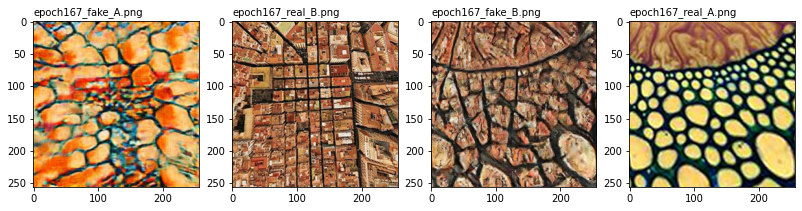

In [ ]:
#######################################################################################
#######################################################################################

import os
import cv2 #to load images. From module OpenCV
import matplotlib.pyplot as plt

#image sizes
imagesize = 256
colorConversion= cv2.COLOR_BGR2RGB

#read files
files = os.listdir(path)
files.sort(key=lambda r:r[0])

#plot figure
fig=plt.figure("Test Results")
plotwidth = 0
plotheight = 0


for x in range(len(files)-4, len(files)):
  img=cv2.imread(os.path.join(path, files[x]))

  #print(file)
  imgResized = cv2.resize(img,(imagesize,imagesize))
  imgConverted = cv2.cvtColor(imgResized, colorConversion)

  #print("plot size " + str(img.shape[0]*4) + " : " + str(img.shape[0]*(len(files)/4)))
  plotwidth = imgConverted.shape[0]*4
  plotheight = imgConverted.shape[0]*(len(files)/4)
  
  #fig.set_size_inches(plotwidth/4,plotheight/4, False)
  fig.set_figwidth(plotwidth/75, True)#inches
  fig.set_figheight(plotheight/75, True)#inches
  ax=fig.add_subplot(1,4,len(files)-x)

  plt.text(0,-10,str(files[x]))
  plt.imshow(imgConverted)
  plt.axis("on")

#show the figure
plt.show();

## **04_TESTING**

Set cd (current directory)

In [ ]:
cd /content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs

/content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs


In [ ]:
!python test.py --dataset_path ./datasets/Nature2Urban --name Nature2Urban --model cyclegan --load_size 256 --batch_size 1 --gpu_ids 0





------------------------------------------ Options ----------------------------------------
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
        data_loading_time: False                         
             dataset_mode: unaligned                     
             dataset_path: ./datasets/Nature2Urban       	[default: None]
                direction: AtoB                          
                     eval: False                         
                  gpu_ids: 0                             
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
               load_epoch: latest                        
                load_iter: 0                             	[default: 0]
                load_size: 256                 

#### Visualize Test results

In [ ]:
path = "/content/drive/My Drive/Shaoting_Zeng/NeuralNetworks/CycleGANs/results/Nature2Urban/test_latest/samples"

In [ ]:
import os
import cv2 #to load images. From module OpenCV
import matplotlib.pyplot as plt

#image sizes
imagesize = 256
colorConversion= cv2.COLOR_BGR2RGB

#read files
files = os.listdir(path)
files.sort(key=lambda r:r[0])

#plot figure
fig=plt.figure("Test Results")
plotwidth = 0
plotheight = 0

i = -1

for file in files:
  i+=1
  img=cv2.imread(os.path.join(path, file))

  #print(file)
  imgResized = cv2.resize(img,(imagesize,imagesize))
  imgConverted = cv2.cvtColor(imgResized, colorConversion)

  #print("plot size " + str(img.shape[0]*4) + " : " + str(img.shape[0]*(len(files)/4)))
  plotwidth = imgConverted.shape[0]*4
  plotheight = imgConverted.shape[0]*(len(files)/4)
  
  #fig.set_size_inches(plotwidth/4,plotheight/4, False)
  fig.set_figwidth(plotwidth/75, True)#inches
  fig.set_figheight(plotheight/75+(len(files)/4)/3, True)#inches
  ax=fig.add_subplot(len(files)/4,4,i+1)

  plt.text(0,-10,file)
  plt.imshow(imgConverted)
  plt.axis("on")

#show the figure
plt.show();
plt.savefig("test")

Output hidden; open in https://colab.research.google.com to view.